# Phase 3 — Multi-model benchmark

Five classifiers with **default** hyperparameters are compared with **5-fold stratified CV** (accuracy, precision, recall, F1, ROC-AUC). The **two best** models by mean ROC-AUC receive `GridSearchCV`. We then fit **XGBoost** (primary) and **Logistic Regression** (interpretable baseline) for saving with `joblib`, using tuned pipelines when those models were in the top two; otherwise a focused grid search is run so artifacts exist for later phases.

**Export:** the final code cell writes [`reports/model_benchmark.json`](../reports/model_benchmark.json) for the README and for reproducible metrics.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebook":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier

from src.preprocessing import build_preprocessing_pipeline, load_heart_csv

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ("accuracy", "precision", "recall", "f1", "roc_auc")


In [2]:
DATA_PATH = ROOT / "data" / "heart-disease.csv"
X, y = load_heart_csv(DATA_PATH)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_train.shape, X_test.shape


((242, 13), (61, 13))

In [3]:
def make_full_pipeline(classifier) -> Pipeline:
    return Pipeline(
        [
            ("prep", build_preprocessing_pipeline()),
            ("clf", classifier),
        ]
    )


MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "SVM": SVC(kernel="rbf", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        objective="binary:logistic",
        eval_metric="logloss",
    ),
    "k-NN": KNeighborsClassifier(n_jobs=-1),
}


In [4]:
rows = []
for name, clf in MODELS.items():
    pipe = make_full_pipeline(clf)
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=CV,
        scoring=list(SCORING),
        n_jobs=-1,
        return_train_score=False,
    )
    row = {"model": name}
    for m in SCORING:
        key = f"test_{m}"
        row[f"{m}_mean"] = float(np.mean(scores[key]))
        row[f"{m}_std"] = float(np.std(scores[key]))
    rows.append(row)

bench = pd.DataFrame(rows).set_index("model")
bench.sort_values("roc_auc_mean", ascending=False)


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
model,,,,,,,,,,
SVM,0.809779,0.055357,0.823250,0.057293,0.833048,0.089181,0.825307,0.056325,0.896232,0.035970
Logistic Regression,0.821939,0.071050,0.820433,0.063152,0.862393,0.093635,0.839247,0.069465,0.889070,0.036846
Random Forest,0.814031,0.049265,0.830037,0.058690,0.833618,0.056136,0.830238,0.043748,0.886888,0.040803
XGBoost,0.797534,0.076807,0.823416,0.075588,0.802564,0.079316,0.811844,0.073365,0.871860,0.052377
k-NN,0.797619,0.047574,0.811178,0.023772,0.818234,0.084460,0.813161,0.051809,0.870487,0.050236


In [5]:
display_cols = [c for c in bench.columns if c.endswith("_mean")]
summary = bench[display_cols].round(4)
summary


,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
model,,,,,
Logistic Regression,0.8219,0.8204,0.8624,0.8392,0.8891
SVM,0.8098,0.8233,0.8330,0.8253,0.8962
Random Forest,0.8140,0.8300,0.8336,0.8302,0.8869
XGBoost,0.7975,0.8234,0.8026,0.8118,0.8719
k-NN,0.7976,0.8112,0.8182,0.8132,0.8705


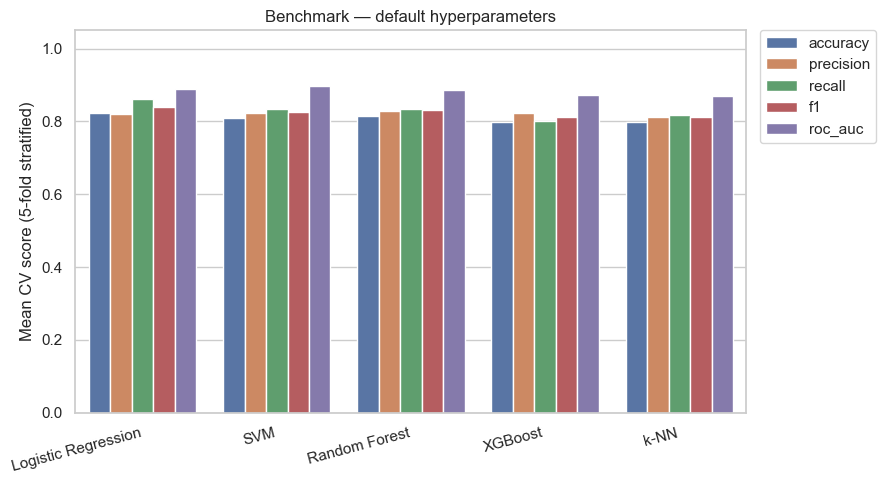

In [6]:
plot_df = bench.reset_index().melt(
    id_vars=["model"],
    value_vars=[f"{m}_mean" for m in SCORING],
    var_name="metric",
    value_name="score",
)
plot_df["metric"] = plot_df["metric"].str.replace("_mean", "", regex=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_df, x="model", y="score", hue="metric", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_xlabel("")
ax.set_ylabel("Mean CV score (5-fold stratified)")
ax.set_title("Benchmark — default hyperparameters")
plt.xticks(rotation=15, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()


## Hyperparameter tuning (two best by ROC-AUC)

`GridSearchCV` with the same CV splitter, scoring ROC-AUC.


In [7]:
PARAM_GRIDS = {
    "Logistic Regression": {
        "clf__C": [0.01, 0.1, 1.0, 10.0],
    },
    "SVM": {
        "clf__C": [0.1, 1.0, 10.0],
        "clf__gamma": ["scale", "auto"],
    },
    "Random Forest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [None, 4, 8],
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [3, 5],
        "clf__learning_rate": [0.05, 0.1, 0.2],
        "clf__subsample": [0.9, 1.0],
        "clf__colsample_bytree": [0.9, 1.0],
    },
    "k-NN": {
        "clf__n_neighbors": [3, 5, 7, 11],
        "clf__weights": ["uniform", "distance"],
    },
}

ranked = bench.sort_values("roc_auc_mean", ascending=False)
top_two = list(ranked.index[:2])
top_two


['SVM', 'Logistic Regression']

In [8]:
tuned = {}
for name in top_two:
    grid = GridSearchCV(
        estimator=make_full_pipeline(MODELS[name]),
        param_grid=PARAM_GRIDS[name],
        scoring="roc_auc",
        cv=CV,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train)
    tuned[name] = grid

for name, grid in tuned.items():
    print(name, "best_params:", grid.best_params_, "best_cv_roc_auc:", round(grid.best_score_, 4))


SVM best_params: {'clf__C': 1.0, 'clf__gamma': 'scale'} best_cv_roc_auc: 0.8962
Logistic Regression best_params: {'clf__C': 0.01} best_cv_roc_auc: 0.899


## Persist XGBoost (primary) and Logistic Regression (baseline)

If either model was not among the two tuned above, we run a focused `GridSearchCV` for that model alone so both artifacts exist for SHAP / DiCE later.


In [9]:
def ensure_tuned(name: str) -> GridSearchCV:
    if name in tuned:
        return tuned[name]
    grid = GridSearchCV(
        estimator=make_full_pipeline(MODELS[name]),
        param_grid=PARAM_GRIDS[name],
        scoring="roc_auc",
        cv=CV,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train)
    return grid


xgb_search = ensure_tuned("XGBoost")
lr_search = ensure_tuned("Logistic Regression")

ARTIFACT_DIR = ROOT / "models"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(xgb_search.best_estimator_, ARTIFACT_DIR / "xgboost_pipeline.joblib")
joblib.dump(lr_search.best_estimator_, ARTIFACT_DIR / "logistic_regression_pipeline.joblib")

print("Saved:", ARTIFACT_DIR / "xgboost_pipeline.joblib")
print("Saved:", ARTIFACT_DIR / "logistic_regression_pipeline.joblib")


Saved: /Users/gabrielesantoro/heart-risk-advisor/models/xgboost_pipeline.joblib
Saved: /Users/gabrielesantoro/heart-risk-advisor/models/logistic_regression_pipeline.joblib


In [10]:
def report_holdout(search: GridSearchCV, label: str) -> None:
    preds = search.best_estimator_.predict(X_test)
    proba = None
    if hasattr(search.best_estimator_.named_steps["clf"], "predict_proba"):
        proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    elif hasattr(search.best_estimator_.named_steps["clf"], "decision_function"):
        proba = search.best_estimator_.decision_function(X_test)
    auc = roc_auc_score(y_test, proba)
    print(f"=== {label} (hold-out) ROC-AUC: {auc:.4f} ===")
    print(classification_report(y_test, preds, digits=4))


report_holdout(xgb_search, "XGBoost")
report_holdout(lr_search, "Logistic Regression")


=== XGBoost (hold-out) ROC-AUC: 0.8582 ===
              precision    recall  f1-score   support

           0     0.8261    0.6786    0.7451        28
           1     0.7632    0.8788    0.8169        33

    accuracy                         0.7869        61
   macro avg     0.7946    0.7787    0.7810        61
weighted avg     0.7920    0.7869    0.7839        61

=== Logistic Regression (hold-out) ROC-AUC: 0.9297 ===
              precision    recall  f1-score   support

           0     0.9048    0.6786    0.7755        28
           1     0.7750    0.9394    0.8493        33

    accuracy                         0.8197        61
   macro avg     0.8399    0.8090    0.8124        61
weighted avg     0.8346    0.8197    0.8154        61



In [ ]:
import json
from sklearn.metrics import accuracy_score

REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)


def _holdout_metrics(search: GridSearchCV) -> dict[str, float]:
    est = search.best_estimator_
    preds = est.predict(X_test)
    if hasattr(est.named_steps["clf"], "predict_proba"):
        proba = est.predict_proba(X_test)[:, 1]
    else:
        proba = est.decision_function(X_test)
    return {
        "roc_auc": float(roc_auc_score(y_test, proba)),
        "accuracy": float(accuracy_score(y_test, preds)),
    }


def _json_safe(obj):
    if isinstance(obj, dict):
        return {k: _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(v) for v in obj]
    if hasattr(obj, "item"):
        return obj.item()
    return obj


benchmark_report = {
    "meta": {
        "source_notebook": "notebook/modeling.ipynb",
        "random_state": RANDOM_STATE,
        "train_rows": int(X_train.shape[0]),
        "test_rows": int(X_test.shape[0]),
        "cv": "5-fold StratifiedKFold (shuffle=True)",
        "benchmark_note": (
            "Default hyperparameters for all five models; mean ROC-AUC ranks models. "
            "Top two receive GridSearchCV. XGBoost and Logistic Regression are always "
            "tuned and saved for the app (SHAP/DiCE) and a linear baseline."
        ),
    },
    "cross_validation_default_hyperparameters": _json_safe(
        bench.round(6).reset_index().rename(columns={"index": "model"}).to_dict(orient="records")
    ),
    "ranking_by_mean_roc_auc": bench.sort_values("roc_auc_mean", ascending=False).index.tolist(),
    "grid_search_on_top_two_defaults": {
        "models": top_two,
        "best_cv_roc_auc": {n: float(tuned[n].best_score_) for n in top_two},
        "best_params": _json_safe({n: tuned[n].best_params_ for n in top_two}),
    },
    "tuned_pipelines_saved": {
        "xgboost": {
            "best_cv_roc_auc": float(xgb_search.best_score_),
            "best_params": _json_safe(xgb_search.best_params_),
        },
        "logistic_regression": {
            "best_cv_roc_auc": float(lr_search.best_score_),
            "best_params": _json_safe(lr_search.best_params_),
        },
    },
    "holdout_test_set": {
        "xgboost": _holdout_metrics(xgb_search),
        "logistic_regression": _holdout_metrics(lr_search),
    },
}

out_path = REPORTS_DIR / "model_benchmark.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(benchmark_report, f, indent=2)
print("Wrote", out_path)
